In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
os.getcwd()

df = pd.read_csv("student_habits_performance.csv")
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
df.shape


(1000, 16)

In [5]:
df.isnull().sum()


student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [6]:
# Drop missing values
df = df.dropna()

# Check duplicates
df.duplicated().sum()


np.int64(0)

In [7]:
df.describe()


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [8]:
categorical_cols = df.describe(include="object").columns
categorical_cols


Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [9]:
for col in categorical_cols:
    print(f"Value counts for {col}:\n")
    print(df[col].value_counts())
    print("-"*40)


Value counts for student_id:

student_id
S1000    1
S1001    1
S1002    1
S1003    1
S1004    1
        ..
S1995    1
S1996    1
S1997    1
S1998    1
S1999    1
Name: count, Length: 909, dtype: int64
----------------------------------------
Value counts for gender:

gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
----------------------------------------
Value counts for part_time_job:

part_time_job
No     713
Yes    196
Name: count, dtype: int64
----------------------------------------
Value counts for diet_quality:

diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
----------------------------------------
Value counts for parental_education_level:

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
----------------------------------------
Value counts for internet_quality:

internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
---------------

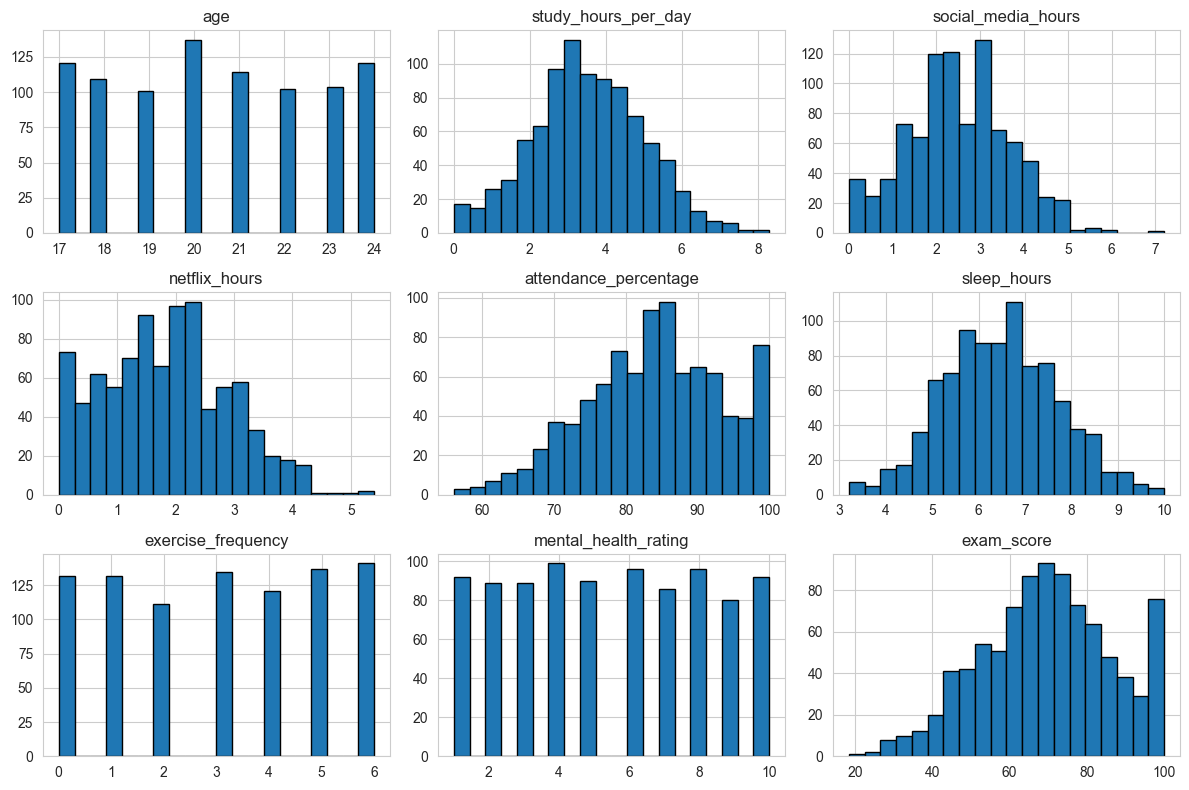

In [10]:
df.hist(bins=20, edgecolor="black", figsize=(12,8))
plt.tight_layout()
plt.show()


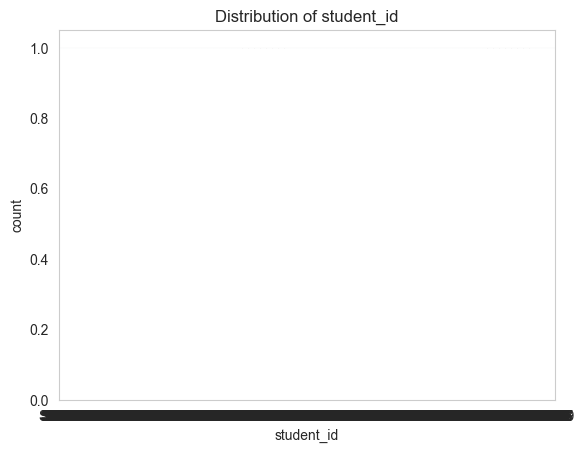

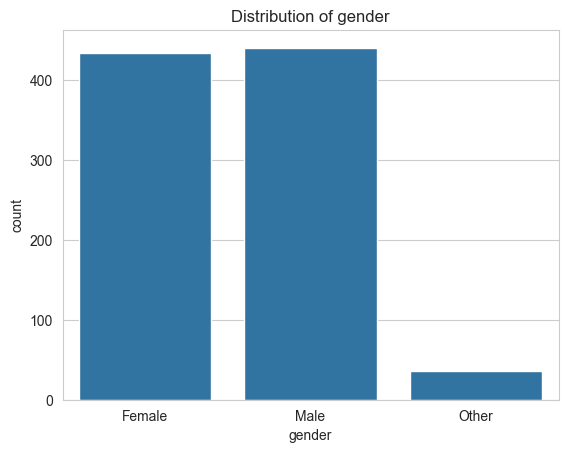

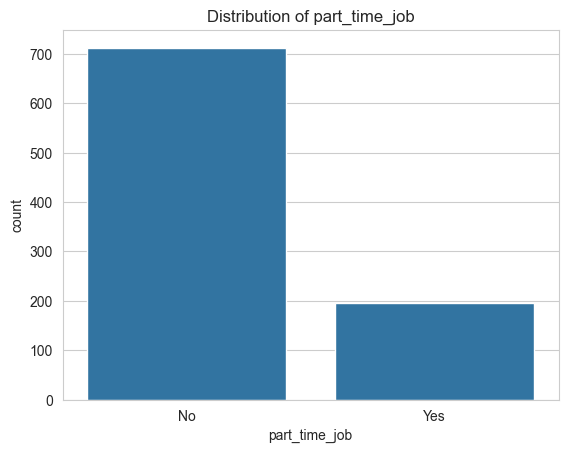

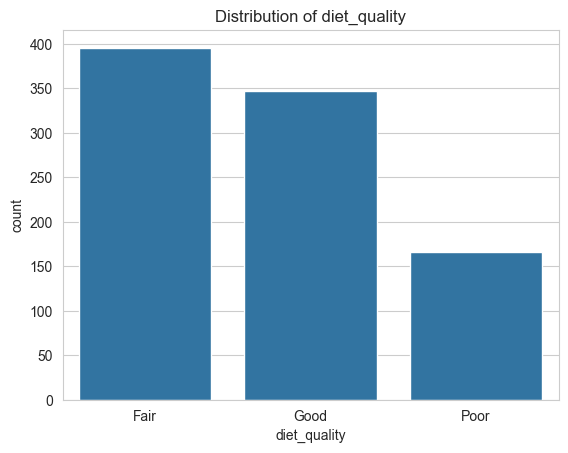

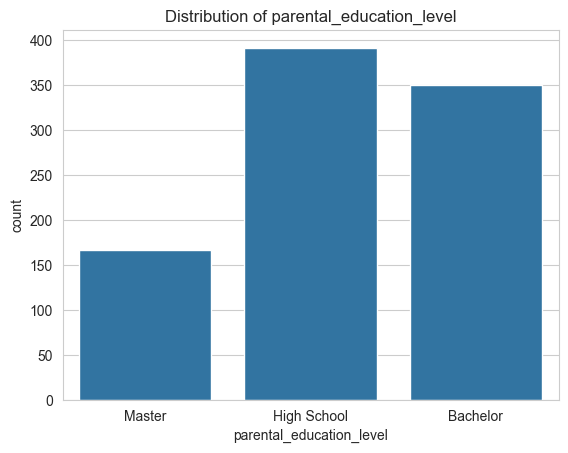

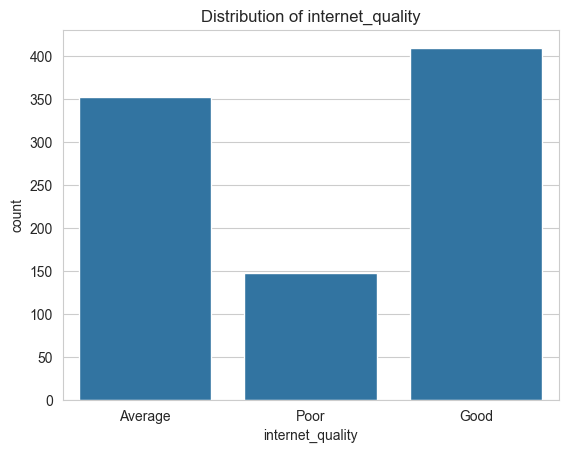

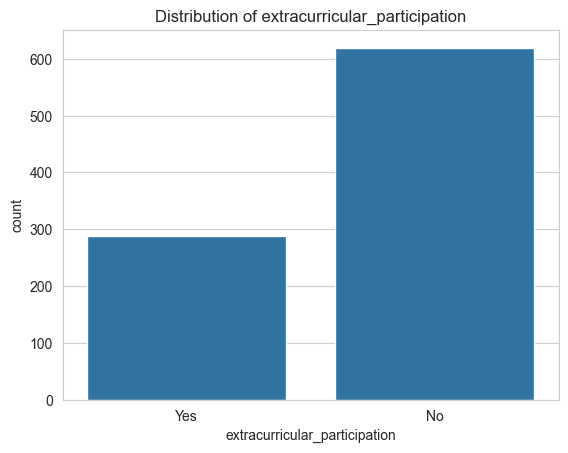

In [11]:
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()


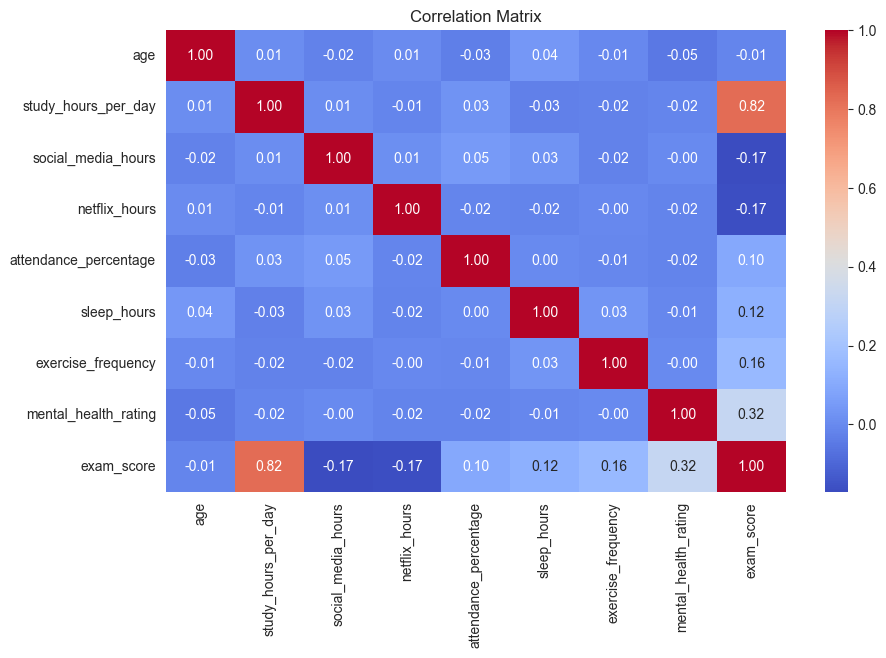

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


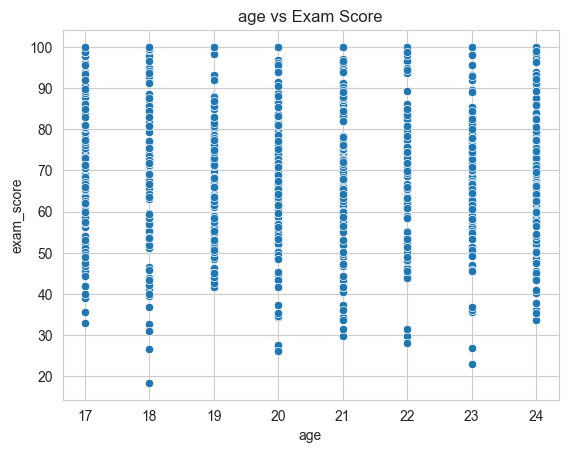

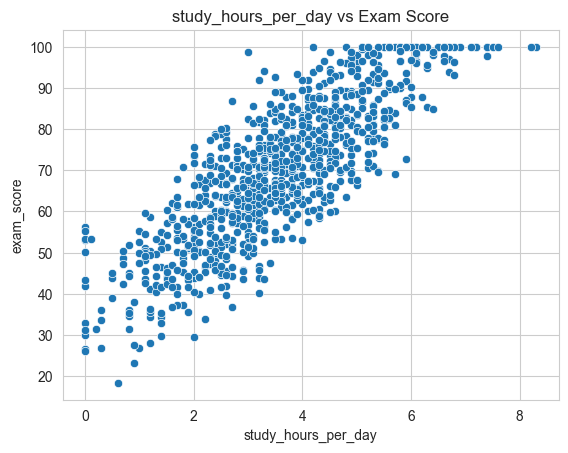

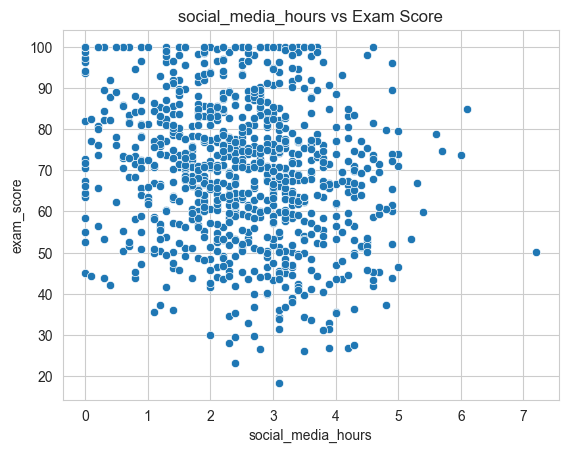

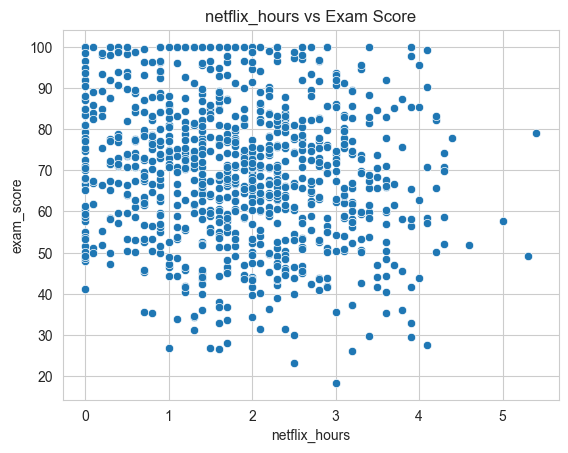

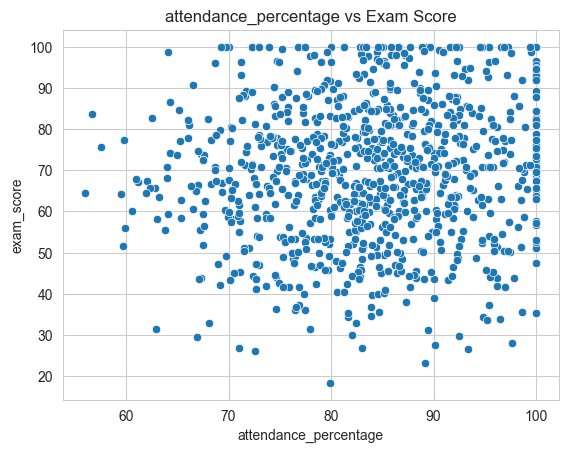

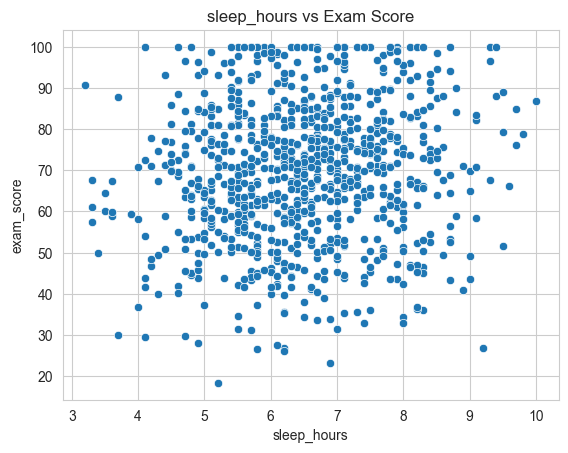

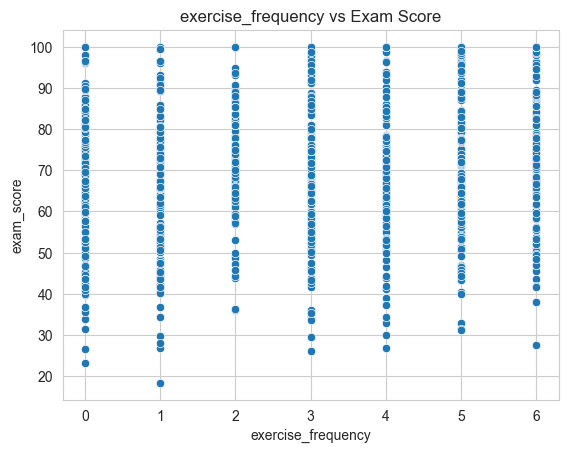

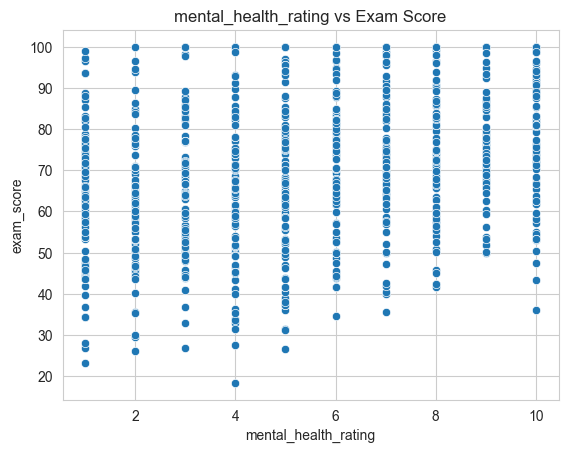

In [13]:
num_features = [
    "age", "study_hours_per_day", "social_media_hours",
    "netflix_hours", "attendance_percentage",
    "sleep_hours", "exercise_frequency",
    "mental_health_rating"
]

for feature in num_features:
    sns.scatterplot(data=df, x=feature, y="exam_score")
    plt.title(f"{feature} vs Exam Score")
    plt.show()


In [14]:
features = [
    "study_hours_per_day",
    "attendance_percentage",
    "part_time_job",
    "sleep_hours",
    "mental_health_rating"
]

target = "exam_score"

df_model = df[features + [target]].copy()
df_model.head()


,study_hours_per_day,attendance_percentage,part_time_job,sleep_hours,mental_health_rating,exam_score
0,0.0,85.0,No,8.0,8,56.2
1,6.9,97.3,No,4.6,8,100.0
2,1.4,94.8,No,8.0,1,34.3
3,1.0,71.0,No,9.2,1,26.8
4,5.0,90.9,No,4.9,1,66.4


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model["part_time_job"] = le.fit_transform(df_model["part_time_job"])


In [16]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


In [18]:
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [5, 10]
        }
    }
}


In [19]:
results = []

for name, config in models.items():
    print(f"Training {name}...")

    grid = GridSearchCV(
        config["model"],
        config["params"],
        cv=5,
        scoring="neg_mean_squared_error"
    )

    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "RMSE": rmse,
        "R2 Score": r2
    })


Training Linear Regression...
Training Decision Tree...
Training Random Forest...


In [20]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")


,Model,Best Params,RMSE,R2 Score
2,Random Forest,"{'max_depth': 10, 'n_estimators': 100}",7.109658,0.813776
0,Linear Regression,{},7.190938,0.809494
1,Decision Tree,"{'max_depth': 5, 'min_samples_split': 5}",7.989826,0.764814


In [21]:
best_row = results_df.sort_values(by="RMSE").iloc[0]

best_model_name = best_row["Model"]
best_params = best_row["Best Params"]

final_model = models[best_model_name]["model"].set_params(**best_params)
final_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
import joblib

joblib.dump(final_model, "model.pkl")


['model.pkl']

In [23]:
loaded_model = joblib.load("model.pkl")
loaded_model.predict(X_test.head())


array([59.50460633, 51.82089754, 69.49592026, 78.1910219 , 94.6580303 ])